In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample, shuffle
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

# Preparación de los Datos
Primero, se deben cargar los datos y realizar una limpieza selectiva.

In [2]:
df = pd.read_csv('../data/Churn.csv')

# Visualizar las primeras filas y estructura
print(df.info())
display(df.head())

# Revisar valores ausentes
print("\nValores nulos por columna:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.1 MB
None


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0



Valores nulos por columna:
 RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64


De acuerdo a los datos cargados se propone las siguientes acciones: 
1. __Eliminación de Irrelevantes__: Columnas como RowNumber, CustomerId y Surname no aportan valor predictivo y pueden causar sobreajuste. Deben eliminarse.
2. __Tratamiento de Valores Ausentes__: Revisa la columna Tenure. Si hay valores nulos, podrías imputarlos con la mediana o eliminarlos si representan un porcentaje pequeño.
3. __Codificación de Variables Categóricas__: Utiliza One-Hot Encoding (OHE) para Geography y Gender. Asegúrate de usar drop_first=True para evitar la trampa de la multicolinealidad.
4. __Escalado de Características__: Dado que variables como Balance y EstimatedSalary tienen magnitudes muy distintas a Age o NumOfProducts, aplica StandardScaler a las características numéricas.

In [3]:
# 1. Eliminar columnas irrelevantes
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 2. Tratar valores nulos en 'Tenure' 
# Dado que es el tiempo que el cliente lleva en el banco, llenamos con la mediana
df_clean['Tenure'] = df_clean['Tenure'].fillna(df_clean['Tenure'].median())

# 3. Transformación de variables categóricas (OHE)
# Usamos drop_first=True para evitar la trampa de las variables ficticias
df_ohe = pd.get_dummies(df_clean, drop_first=True)

print("Forma del dataset tras preprocesamiento:", df_ohe.shape)

Forma del dataset tras preprocesamiento: (10000, 12)


In [4]:
# Definir características y objetivo
target = df_ohe['Exited']
features = df_ohe.drop('Exited', axis=1)

# División 60% entrenamiento, 20% validación, 20% prueba
features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.40, random_state=12345)

features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.50, random_state=12345)

features_train = features_train.copy()
features_valid = features_valid.copy()
features_test = features_test.copy()

# Escalado de características numéricas
numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
scaler.fit(features_train[numeric])

features_train[numeric] = scaler.transform(features_train[numeric])
features_valid[numeric] = scaler.transform(features_valid[numeric])
features_test[numeric] = scaler.transform(features_test[numeric])

# ¿Desequilibrio o equilibrio de clases?

In [5]:
# Examinar equilibrio
print(target_train.value_counts(normalize=True))

# Entrenar modelo sin considerar el desequilibrio
model_base = RandomForestClassifier(random_state=12345, n_estimators=100)
model_base.fit(features_train, target_train)
predicted_valid = model_base.predict(features_valid)

print("Accuracy (Modelo base):", accuracy_score(target_valid, predicted_valid))
print("F1-score (Modelo base):", f1_score(target_valid, predicted_valid))

Exited
0    0.800667
1    0.199333
Name: proportion, dtype: float64
Accuracy (Modelo base): 0.8585
F1-score (Modelo base): 0.5769805680119582


Hay una proporción de aproximadamente 80/20
- Se entrena un modelo base sin considerar desquilibrio
- Se tiene un modelo con exactitud del 85.85%, pero un F1-score debajo del 0.59

In [6]:
# Probamos RandomForest con ajuste automático de pesos
model_weighted = RandomForestClassifier(random_state=12345, n_estimators=100, class_weight='balanced')
model_weighted.fit(features_train, target_train)
predicted_weighted = model_weighted.predict(features_valid)

print("Accuracy (Pesos balanceados):", accuracy_score(target_valid, predicted_weighted))
print("F1-score (Pesos balanceados):", f1_score(target_valid, predicted_weighted))

Accuracy (Pesos balanceados): 0.8615
F1-score (Pesos balanceados): 0.5718701700154559


- Se entrena un modelo con ajuste de peso de clase, es una configuración interna del algoritmo de sklearn que penaliza más los errores en la clase minoritaria.
- Se tiene una exactitud parecida al modelo Base pero aun F1-Score debajo de lo solicitado

In [7]:
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
    
    features_upsampled, target_upsampled = shuffle(features_upsampled, target_upsampled, random_state=12345)
    
    return features_upsampled, target_upsampled

features_upsampled, target_upsampled = upsample(features_train, target_train, 4)

# Entrenar con datos aumentados

model_upsampled = RandomForestClassifier(random_state=12345, n_estimators=100)
model_upsampled.fit(features_upsampled, target_upsampled)
predicted_upsampled = model_upsampled.predict(features_valid)


print("Accuracy (Upsampling):", accuracy_score(target_valid, predicted_upsampled))
print("F1-score (Upsampling):", f1_score(target_valid, predicted_upsampled))

Accuracy (Upsampling): 0.852
F1-score (Upsampling): 0.6084656084656085


- Se propone aplicar Sobremuestro, duplicar aleatoriamente instancias de la clase minoritaria (Exited == 1) en el conjuto de entrenamiento
- Se conserva la exactitud y se optiene un F1-score mayor de 0.59, por el momento el mejor modelo. 

In [8]:
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat([features_zeros.sample(frac=fraction, random_state=12345)] + [features_ones])
    target_downsampled = pd.concat([target_zeros.sample(frac=fraction, random_state=12345)] + [target_ones])

    features_downsampled, target_downsampled = shuffle(features_downsampled, target_downsampled, random_state=12345)

    return features_downsampled, target_downsampled

features_downsampled, target_downsampled = downsample(features_train, target_train, 0.1)

model_downsampled = RandomForestClassifier(random_state=12345, n_estimators=100)
model_downsampled.fit(features_downsampled, target_downsampled)
predicted_downsampled = model_downsampled.predict(features_valid)

print("Accuracy (Downsampling):", accuracy_score(target_valid, predicted_downsampled))
print("F1-score (Downsampling):", f1_score(target_valid, predicted_downsampled))

Accuracy (Downsampling): 0.583
F1-score (Downsampling): 0.4701397712833545


- Ahora con Submuestreo, eliminar aleatoriamente instancias de la clase mayoritaria.
- Se tiene el peor modelo con una exactitud baja y F1-Score muy bajo, por lanto se decarta este modelo

# Evaluación Final y AUC-ROC

El mejor modelo que resulto fue el Clasificador de bosque aleatorio de 100 estimadores con sobremuestreo, ahora se implenta el modelo entrenado con los conjuntos de prueba para su evaluación final y el cálculo de AUC-ROC y el trazado de la curva ROC. 

F1 Final en Test: 0.5898
AUC-ROC Final: 0.8464


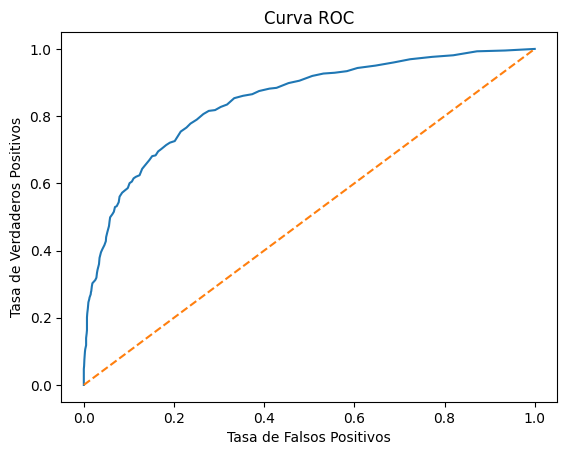

In [9]:
# Usamos el mejor modelo encontrado 
final_model = model_upsampled 

# Predicciones en el conjunto de prueba
test_predictions = final_model.predict(features_test)
test_f1 = f1_score(target_test, test_predictions)

# Cálculo de AUC-ROC
probabilities_test = final_model.predict_proba(features_test)[:, 1]
auc_roc = roc_auc_score(target_test, probabilities_test)

print(f"F1 Final en Test: {test_f1:.4f}")
print(f"AUC-ROC Final: {auc_roc:.4f}")

# Graficar curva ROC
fpr, tpr, thresholds = roc_curve(target_test, probabilities_test)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.show()

La __métrica AUC-ROC__ calcula el érea bajo la curva ROC. MIentras que F1 se centra en un umbral específico, la AUC-ROC evalúa qué tan bien el modelo distingue entre clases en todos los umbrales posibles. 

A pesar de tener un F1-score en conjunto de validación de 0.60, al momento de probar con los conjuntos test se tiene un F1- score de 0.58 menor al 0.59 que se solicita. Será buena idea una busqueda en el hiperparametro del número de estimadores? 

In [10]:
best_nEstimator=0
best_f1=0
for estimator in range(1,100):
    model_upsampled = RandomForestClassifier(random_state=12345, n_estimators=estimator)
    model_upsampled.fit(features_upsampled, target_upsampled)
    predicted_upsampled = model_upsampled.predict(features_valid)
    f1 = f1_score (target_valid, predicted_upsampled)
    if f1 > best_f1:
        best_f1 = f1
        best_nEstimator = estimator

print(f"Mejor modelo: F1-score={best_f1:.4f} en número de estimadores {best_nEstimator}")

Mejor modelo: F1-score=0.6144 en número de estimadores 97


Exactitud final: 0.8440
F1 Final en Test: 0.5948
AUC-ROC Final: 0.8464


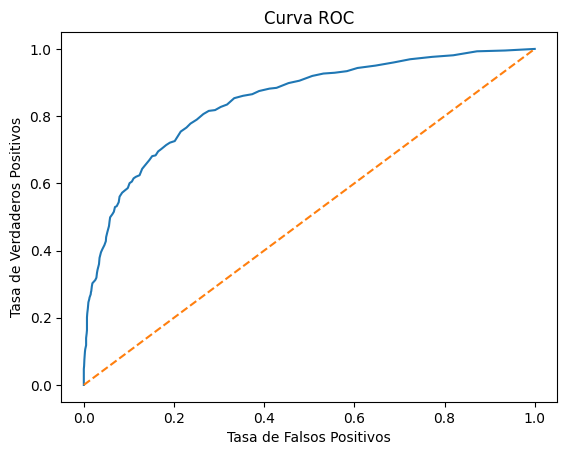

In [11]:
model_final = RandomForestClassifier(random_state=12345, n_estimators=97)
model_final.fit(features_upsampled, target_upsampled)

# Predicciones en el conjunto de prueba
test_predictions = model_final.predict(features_test)
test_f1 = f1_score(target_test, test_predictions)

# Cálculo de AUC-ROC
probabilities_test = final_model.predict_proba(features_test)[:, 1]
auc_roc = roc_auc_score(target_test, probabilities_test)

print(f"Exactitud final: {accuracy_score(target_test, test_predictions):.4f}")
print(f"F1 Final en Test: {test_f1:.4f}")
print(f"AUC-ROC Final: {auc_roc:.4f}")

# Graficar curva ROC
fpr, tpr, thresholds = roc_curve(target_test, probabilities_test)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.show()

- Se tiene un modelo final con una Exactitud del 84.4%, un F1-score de 0.5948 justo a lo solicitado, aunque en validación se tiene un valor de 0.6144. El AUC-ROC final es igual a 0.8464. 

- Se tiene una Curva ROC, se puede interpretar por lo alto se su curva el modelo es de mejor calidad que un modelo que responde de forma aleatoria. 